
# Advanced Lung Cancer Detection using EfficientNet + Grad-CAM

This notebook implements a production-grade deep learning pipeline for lung cancer histopathology classification using:

- Transfer Learning (EfficientNetB0)
- Advanced augmentation
- Fine-tuning
- Grad-CAM explainability
- Class imbalance handling
- Medical evaluation metrics

Classes:
1. Normal
2. Adenocarcinoma
3. Squamous Cell Carcinoma


In [1]:

# Install dependencies (Run only once)
# !pip install tensorflow opencv-python albumentations seaborn scikit-learn

In [2]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.16.1



# Dataset Configuration

Recommended Dataset Structure:

```text
dataset/
    train/
        lung_n/
        lung_aca/
        lung_scc/

    val/
        lung_n/
        lung_aca/
        lung_scc/

    test/
        lung_n/
        lung_aca/
        lung_scc/
```


In [3]:

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 5

train_dir = 'dataset/train'
val_dir = 'dataset/val'
test_dir = 'dataset/test'


# Data Augmentation

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16

dataset_path = '.'

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    dataset_path,
    classes=['lung_aca', 'lung_n', 'lung_scc'],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    dataset_path,
    classes=['lung_aca', 'lung_n', 'lung_scc'],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1920 images belonging to 3 classes.
Found 480 images belonging to 3 classes.


# Visualize Dataset

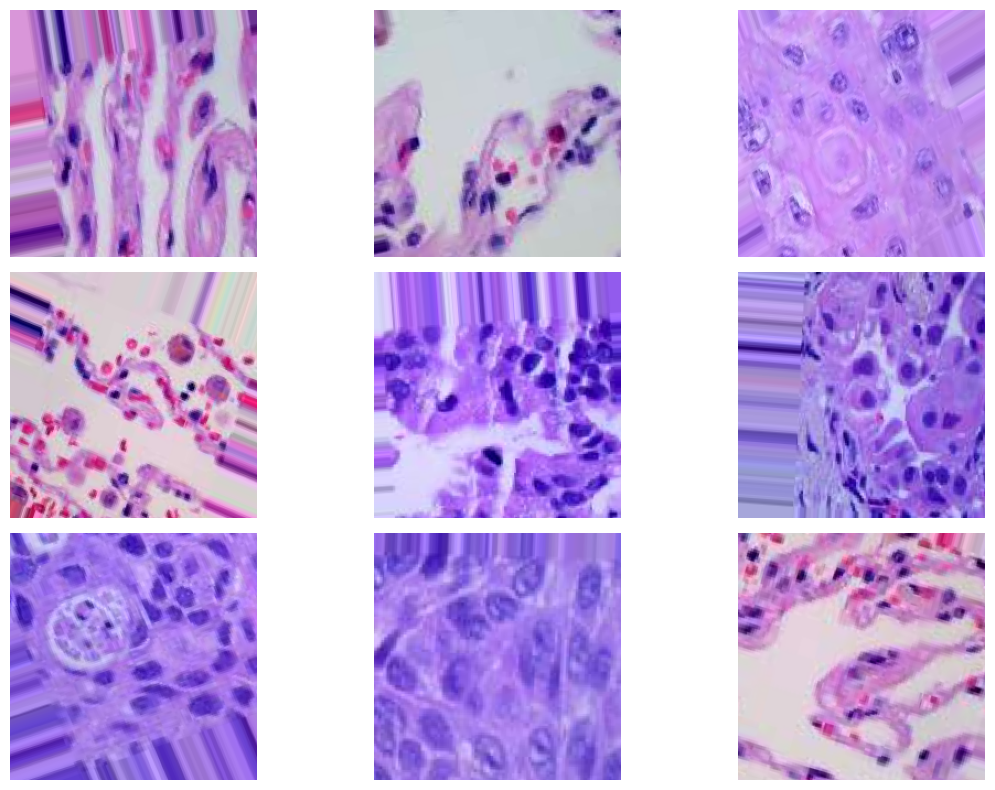

In [5]:

images, labels = next(train_data)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


# Compute Class Weights

In [6]:

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)


{0: 1.0, 1: 1.0, 2: 1.0}


# Build EfficientNet Model

In [7]:

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Compile Model

In [8]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)


# Callbacks

In [9]:

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    ),

    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        save_best_only=True
    )
]


# Train Model

In [10]:

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 83s 596ms/step - accuracy: 0.3443 - auc: 0.5004 - loss: 1.1290 - val_accuracy: 0.3333 - val_auc: 0.5424 - val_loss: 1.0990 - learning_rate: 1.0000e-04
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 67s 559ms/step - accuracy: 0.3318 - auc: 0.5075 - loss: 1.1156 - val_accuracy: 0.3333 - val_auc: 0.5134 - val_loss: 1.0986 - learning_rate: 1.0000e-04
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 564ms/step - accuracy: 0.3276 - auc: 0.5059 - loss: 1.1155 - val_accuracy: 0.3333 - val_auc: 0.4997 - val_loss: 1.0999 - learning_rate: 1.0000e-04
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 67s 558ms/step - accuracy: 0.3375 - auc: 0.5014 - loss: 1.1124 - val_accuracy: 0.3333 - val_auc: 0.5028 - val_loss: 1.0992 - learning_rate: 1.0000e-04
Epoch 5/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 74s 612ms/step - accuracy: 0.3130 - auc: 0.4845 - loss: 1.1150 - val_accuracy: 0.3333 - val_auc: 0.5210 - val_loss: 1.0995 - learning_rate: 5.0000e-05


# Fine-Tuning

In [11]:

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    callbacks=callbacks
)


Epoch 1/3
120/120 ━━━━━━━━━━━━━━━━━━━━ 110s 733ms/step - accuracy: 0.3479 - auc_1: 0.5101 - loss: 1.1348 - val_accuracy: 0.3333 - val_auc_1: 0.5068 - val_loss: 1.0993 - learning_rate: 1.0000e-05
Epoch 2/3
120/120 ━━━━━━━━━━━━━━━━━━━━ 80s 665ms/step - accuracy: 0.3359 - auc_1: 0.5138 - loss: 1.1257 - val_accuracy: 0.3333 - val_auc_1: 0.4933 - val_loss: 1.0996 - learning_rate: 1.0000e-05
Epoch 3/3
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 674ms/step - accuracy: 0.3323 - auc_1: 0.5067 - loss: 1.1261 - val_accuracy: 0.3333 - val_auc_1: 0.5379 - val_loss: 1.0995 - learning_rate: 5.0000e-06


# Training Curves

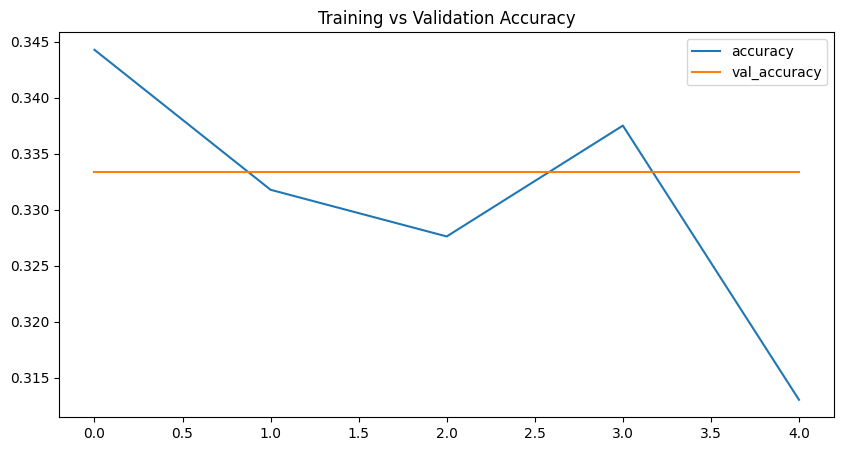

In [12]:

history_df = pd.DataFrame(history.history)

history_df[['accuracy', 'val_accuracy']].plot(figsize=(10,5))
plt.title('Training vs Validation Accuracy')
plt.show()


# Evaluate Model

In [18]:
predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

class_names = list(val_data.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 446ms/step
              precision    recall  f1-score   support

    lung_aca       0.00      0.00      0.00       160
      lung_n       0.00      0.00      0.00       160
    lung_scc       0.33      1.00      0.50       160

    accuracy                           0.33       480
   macro avg       0.11      0.33      0.17       480
weighted avg       0.11      0.33      0.17       480



C:\Users\Dhruv Sharma\anaconda3\envs\lungai311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dhruv Sharma\anaconda3\envs\lungai311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dhruv Sharma\anaconda3\envs\lungai311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

# Confusion Matrix

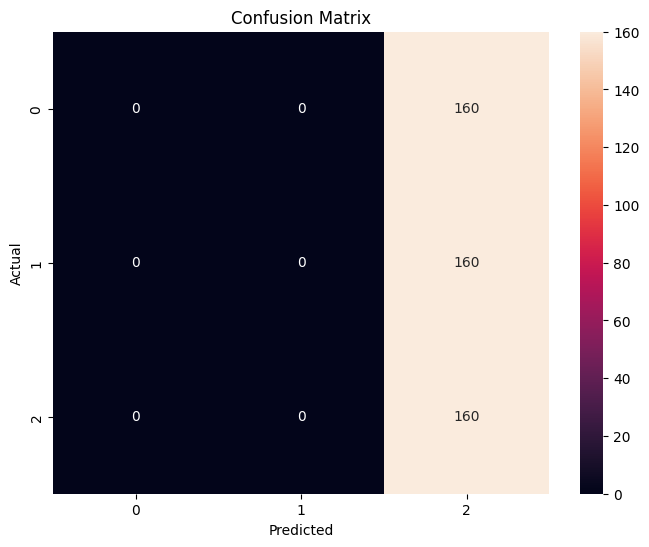

In [19]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()


# Grad-CAM Explainability

In [20]:

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap.numpy()


# Save Model

In [21]:

model.save('lung_cancer_model.keras')

print("Model saved successfully.")


Model saved successfully.



# Next Steps

You can now:

- Deploy using Streamlit
- Add Docker support
- Use larger datasets
- Add Vision Transformers
- Create a medical AI dashboard
- Publish research paper
